# BinWaves example in Cantabria (Validation)

**In this notebook**: 
<br><br>
Here waves are reconstructed at the buoy location for comparison.
<br><br>
Steps:
- Buoy is loaded.
- Kp propagation coefficients and hindcast reconstruction is made at the buoy location.
- Comparison plots and statistics are shown.

In [1]:
import pandas as pd
import xarray as xr
import numpy as np

# Add specific buoy locations
buoy_locations = np.array([
    [514397.61, 4051843.74],  # 36.6120N, -74.8390W -buoy 44088
    [446728.66, 4012728.08],  # 36.2580, -75.5930 (WGS84) - buoy 44100
    [462056.64, 3984141.31],  # 36.0010, -75.4210 (WGS84) - buoy 44086
    [435811.25, 4006367.97],  # 36.2000, -75.7140 (WGS84) - buoy 44056
    [470164.24, 3956270.58],  # 35.7500, -75.3300 (WGS84) - buoy 44095
    [474075.136, 3901692.114], # 35.2580, -75.2850 (WGS84) buoy 41120
    [458576.64, 3874246.18],  # 35.0100, -75.4540 (WGS84) - buoy 41025
])

# Load buoy data and kps

buoy_waves = pd.read_pickle("outputs/buoy_44100_bulk_parameters.pkl").sort_index().loc["2022"]
# buoy_waves = pd.read_pickle("outputs/buoy_44100_bulk_parameters.pkl")
buoy_waves = buoy_waves.dropna(subset=['Hs_Buoy', 'Tp_Buoy', 'Dir_Buoy'])
kp_coeffs = xr.open_dataset("outputs/kp_coefficients.nc").isel(site=[-6])
# kp_coeffs = xr.open_dataset("outputs/kp_coefficients.nc")
kp_coeffs

<xarray.Dataset> Size: 4MB
Dimensions:   (case_num: 696, site: 1, freq: 31, dir: 24)
Coordinates:
  * case_num  (case_num) int64 6kB 0 1 2 3 4 5 6 ... 689 690 691 692 693 694 695
  * site      (site) int64 8B 2
  * freq      (freq) float64 248B 0.03 0.0329 0.0362 ... 0.4145 0.4552 0.5
  * dir       (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
    lat       float64 8B ...
    lon       float64 8B ...
    utm_x     (site) float64 8B ...
    utm_y     (site) float64 8B ...
Data variables:
    kps       (case_num, site, freq, dir) float64 4MB ...

In [2]:
kp_coeffs.utm_x.values, kp_coeffs.utm_y.values

(array([446728.66]), array([4012728.08]))

In [3]:
from utils.operations import transform_ERA5_spectrum
import numpy as np
model_parameters = pd.read_csv("NC_cases/swan_cases.csv").to_dict(orient="list")

# Load interest spectra
offshore_spectra, offshore_spectra_case = (  # Unpack both values from the tuple
    transform_ERA5_spectrum(
        era5_spectrum=xr.open_dataset("outputs/jen_north_carolina_spec_utm_unique.nc"),
        subset_parameters=model_parameters,
        available_case_num=kp_coeffs.case_num.values,
    )
)

# Add coordinates directly to offshore_spectra
# offshore_spectra_case.coords['longitude'] = np.float32(285.161)
# offshore_spectra_case.coords['latitude'] = np.float32(36.6120)

offshore_spectra_case.coords['longitude'] = np.float32(284.407)
offshore_spectra_case.coords['latitude'] = np.float32(36.2580)

# Add attributes to the coordinates
offshore_spectra_case.coords['longitude'].attrs = {
    'units': 'degrees_east',
    'long_name': 'Longitude'
}
offshore_spectra_case.coords['latitude'].attrs = {
    'units': 'degrees_north',
    'long_name': 'Latitude'
}
offshore_spectra_case

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/xarray/core/accessor_dt.py:163: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  field_values = method(freq=freq).values


<xarray.DataArray 'efth' (case_num: 696, time: 405409)> Size: 1GB
array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 7.0847166e-20,
        7.2790246e-20, 6.9479947e-20],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.0095968e-19,
        1.0773933e-19, 1.1075864e-19],
       ...,
       [0.0000000e+00, 3.8440106e-27, 2.4607124e-22, ..., 6.3432267e-12,
        6.6909811e-12, 5.5221825e-12],
       [0.0000000e+00, 2.4330966e-27, 1.5166782e-22, ..., 2.2817579e-12,
        2.6370165e-12, 2.0167759e-12],
       [0.0000000e+00, 4.5172463e-25, 8.0684214e-23, ..., 1.0713248e-12,
        1.1941346e-12, 7.9873337e-13]], shape=(696, 405409), dtype=float32)
Coordinates:
  * case_num   (case_num) int64 6kB 0 1 2 3 4 5 6 ... 690 691 692 693 694 695
    station    int32 4B 133
  * time       (time) datetime64[ns] 3MB 1979-01-01 ... 2025-04-01
    longitude  float32 4B 284.4
    latitude   float32 4B 36.26

In [4]:
# import xarray as xr

# # Load the dataset
# offshore_spectra_case = xr.open_dataset("outputs/jen_north_carolina_spec_utm_unique.nc")


# import numpy as np
# times = offshore_spectra_case.time.to_index()
# unique_times, unique_idx = np.unique(offshore_spectra_case.time.values, return_index=True)
# offshore_spectra_case = offshore_spectra_case.isel(time=unique_idx)
# offshore_spectra_case.to_netcdf("outputs/jen_north_carolina_spec_utm_unique.nc")

In [5]:
from bluemath_tk.waves.binwaves import reconstruc_spectra
# Reconstruct spectra

reconstructed_onshore_spectra = reconstruc_spectra(
    offshore_spectra=offshore_spectra_case.sel(time=buoy_waves.index, method="nearest"),
    kp_coeffs=kp_coeffs,
)
reconstructed_onshore_spectra

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37489 instead
  warnings.warn(
/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 39.59 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.Dataset> Size: 87MB
Dimensions:    (site: 1, freq: 31, dir: 24, time: 14681)
Coordinates:
  * site       (site) int64 8B 2
  * freq       (freq) float64 248B 0.03 0.0329 0.0362 ... 0.4145 0.4552 0.5
  * dir        (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
    lat        float64 8B 0.0
    lon        float64 8B 0.0
    utm_x      (site) float64 8B 4.467e+05
    utm_y      (site) float64 8B 4.013e+06
    station    int32 4B 133
  * time       (time) datetime64[ns] 117kB 2022-01-01 ... 2023-01-01
    longitude  float32 4B 284.4
    latitude   float32 4B 36.26
Data variables:
    kps        (time, site, freq, dir) float64 87MB 0.0 0.0 ... 2.59e-11

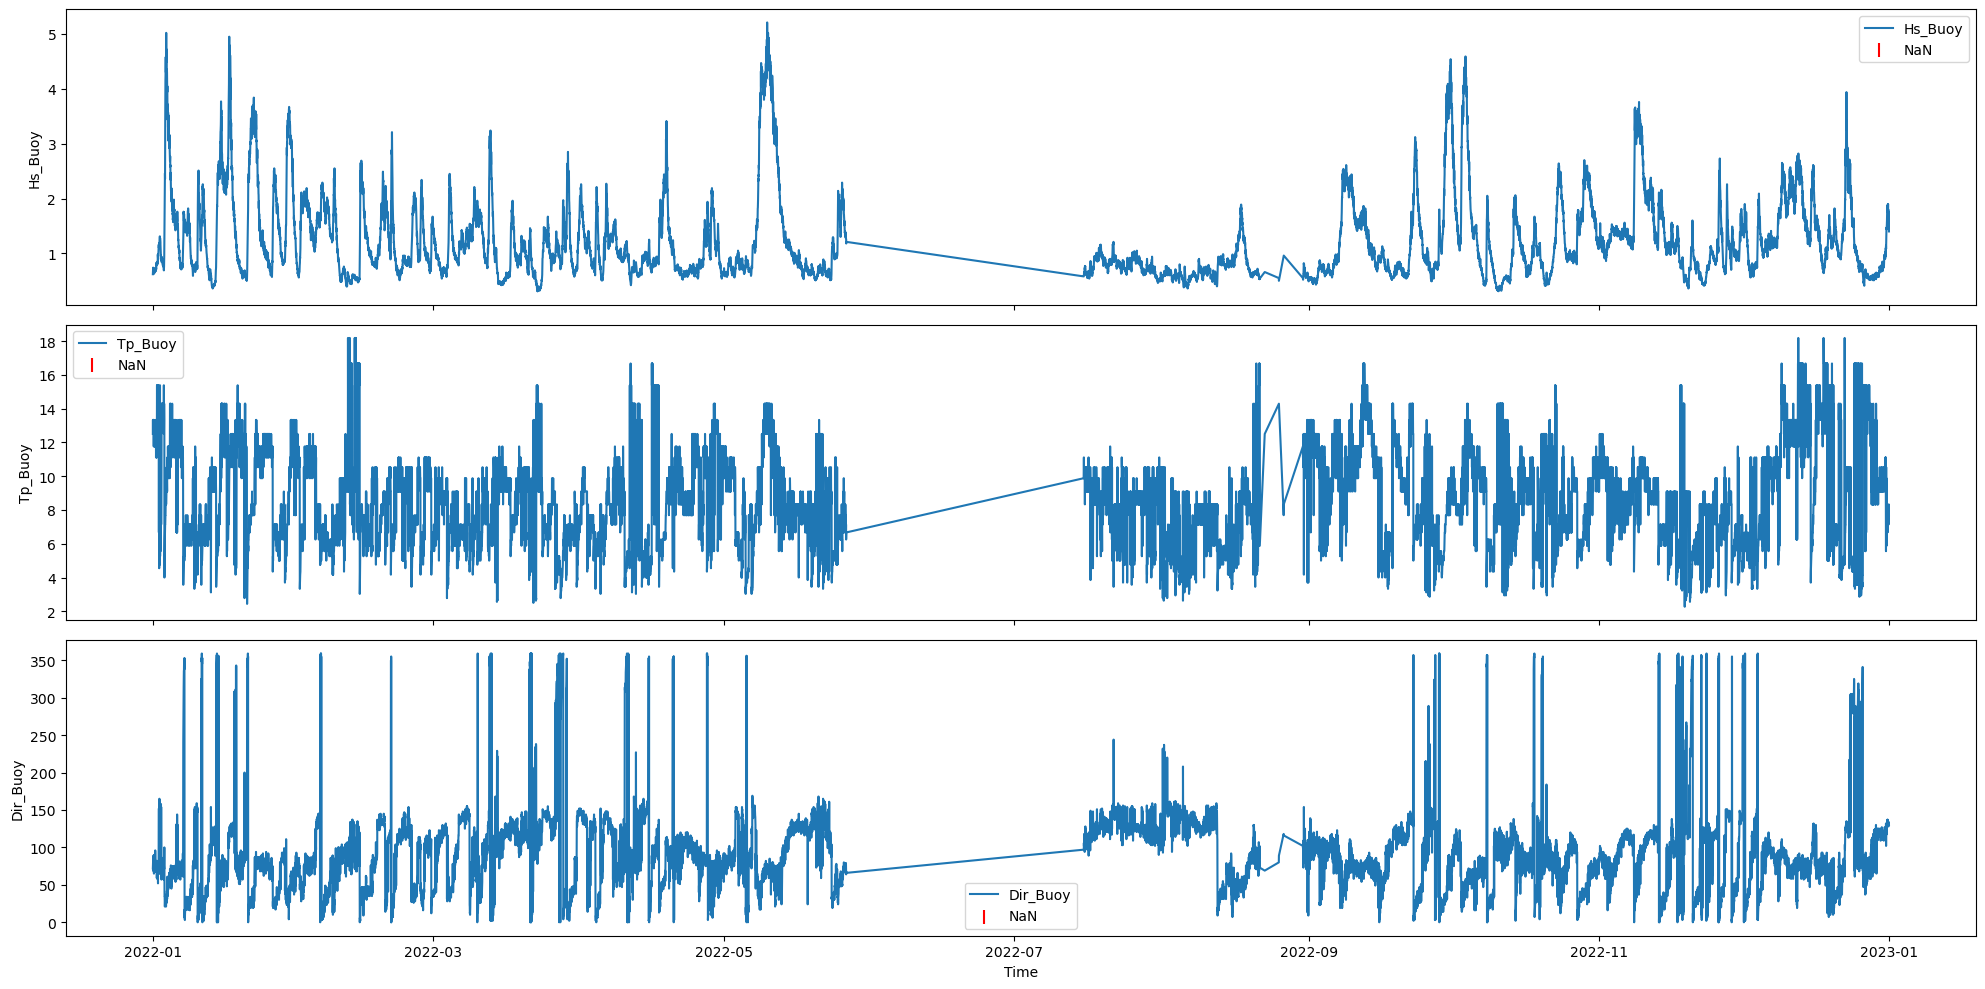

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(20, 10), sharex=True)

for i, var in enumerate(['Hs_Buoy', 'Tp_Buoy', 'Dir_Buoy']):
    axes[i].plot(buoy_waves.index, buoy_waves[var], label=var)
    # Overlay NaN locations
    nan_locs = buoy_waves[var].isna()
    axes[i].scatter(buoy_waves.index[nan_locs], [axes[i].get_ylim()[0]]*nan_locs.sum(), 
                    color='red', marker='|', s=100, label='NaN')
    axes[i].set_ylabel(var)
    axes[i].legend()

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)
/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: xlabel='Hs - Buoy [m]', ylabel='Hs - BinWaves [m]'>,
        <Axes: xlabel='Tp - Buoy [s]', ylabel='Tp - BinWaves [s]'>,
        <Axes: xlabel='Dir - Buoy [°]', ylabel='Dir - BinWaves [°]'>],
       dtype=object))

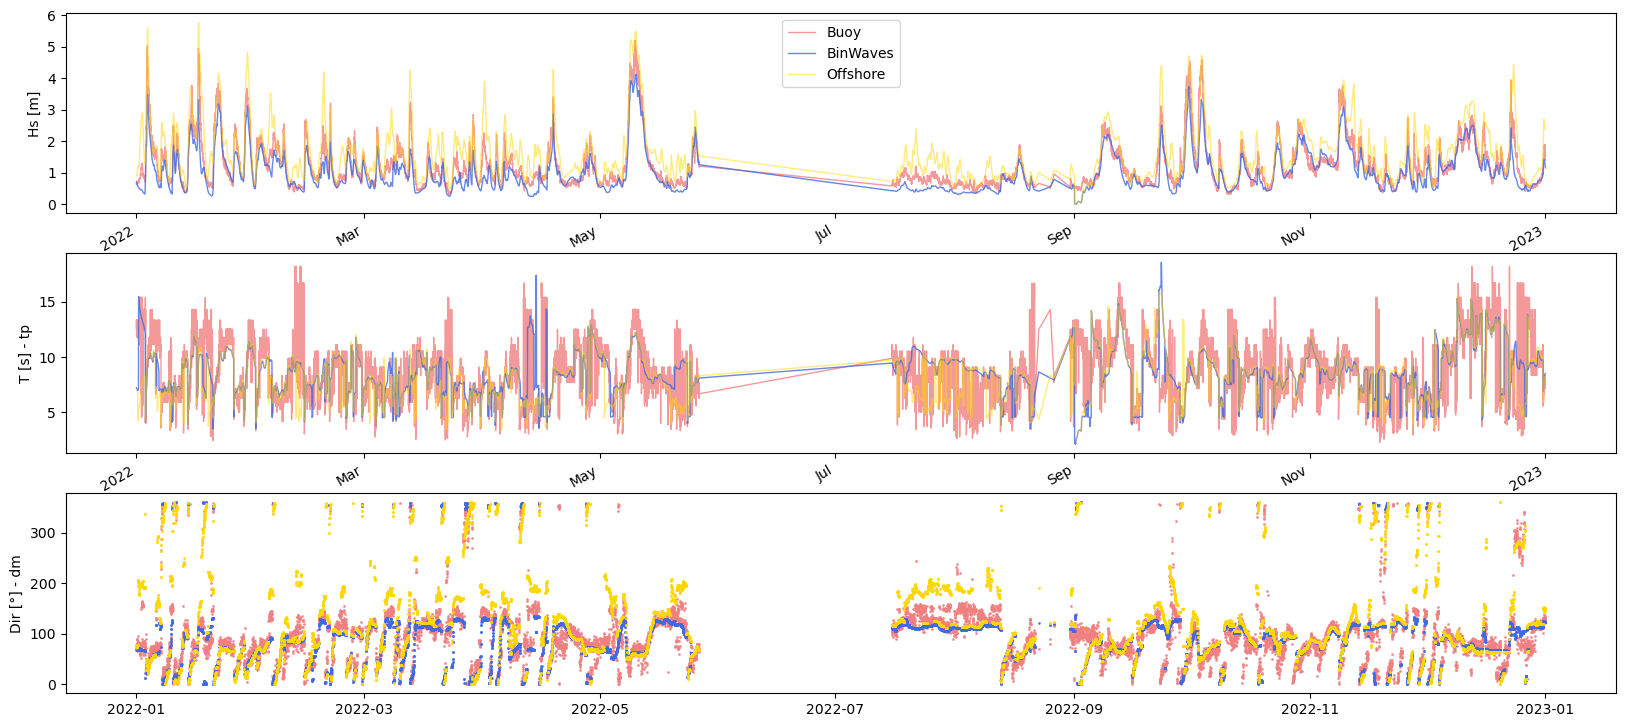

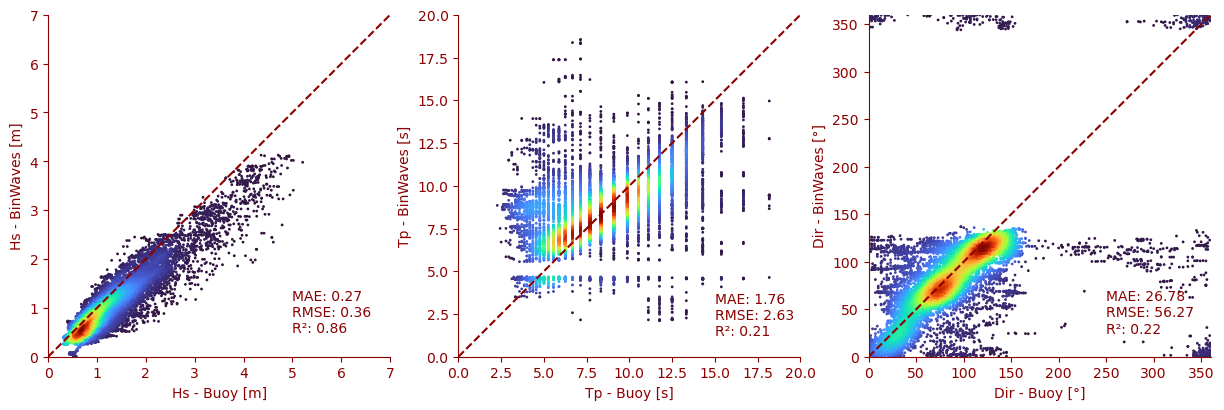

In [7]:
from utils.plotting import plot_wave_series

# Plot reconstructed bulk parameters vs buoy data

# plot_wave_series(
#     buoy_data=buoy_waves,
#     binwaves_data=reconstructed_onshore_spectra.rename({"kps": "efth"})
#     .squeeze()
#     .sel(time=buoy_waves.index, method="nearest")
#     .spec,
#     offshore_data=offshore_spectra.sel(time=buoy_waves.index, method="nearest").spec,
#     times=buoy_waves.index.values,
# )
# Plot reconstructed bulk parameters vs buoy data
plot_wave_series(
    buoy_data=buoy_waves,
    binwaves_data=reconstructed_onshore_spectra.rename({"kps": "efth"})
    .squeeze()
    .drop_duplicates('time')  # Add this line to remove duplicates
    .sel(time=buoy_waves.index, method="nearest")
    .spec,
    offshore_data=offshore_spectra.sel(time=buoy_waves.index, method="nearest").spec,
    times=buoy_waves.index.values,
)

In [8]:
from utils.data_export import save_wave_series_to_csv
save_wave_series_to_csv(
    buoy_data=buoy_waves,
    binwaves_data=reconstructed_onshore_spectra.rename({"kps": "efth"})
        .squeeze()
        .drop_duplicates('time')  # Add this line to remove duplicates
        .sel(time=buoy_waves.index, method="nearest")
        .spec,
    times=buoy_waves.index.values,
    output_file='outputs/test_44100_bulk_parameters.csv'
)
